# Lesson 13.3 - Trustworthy AI (toy fairness & explainability demo)

This notebook demonstrates a practical workflow for fairness diagnostics and basic explainability in a binary classification setting.
        


## Objectives

- Build a toy model with a protected attribute.
- Compute fairness-related metrics.
- Inspect model behavior using interpretable signals.
        


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

np.random.seed(123)
        


## Generate Synthetic Dataset with Protected Attribute


In [2]:
n = 3000
protected = np.random.binomial(1, 0.45, size=n)  # 0/1 group indicator

income_score = np.random.normal(0.0 + 0.3 * protected, 1.0, size=n)
credit_history = np.random.normal(0.2, 1.2, size=n)
debt_ratio = np.random.beta(2, 5, size=n)

# True approval propensity with structural bias term
logit = 0.9 * income_score + 0.6 * credit_history - 2.2 * debt_ratio - 0.35 * protected
prob = 1 / (1 + np.exp(-logit))
y = np.random.binomial(1, prob)

df = pd.DataFrame(
    {
        "income_score": income_score,
        "credit_history": credit_history,
        "debt_ratio": debt_ratio,
        "protected": protected,
        "approved": y,
    }
)

df.head()
        


,income_score,credit_history,debt_ratio,protected,approved
0,0.416603,-1.068969,0.197406,1,0
1,-0.097093,-0.213212,0.194100,0,0
2,1.203193,0.868782,0.310849,0,1
3,0.220291,0.726494,0.716868,1,0
4,0.540631,-1.722355,0.236287,1,0


## Train Baseline Classifier


In [3]:
features = ["income_score", "credit_history", "debt_ratio", "protected"]
X = df[features]
y = df["approved"]
A = df["protected"]

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.30, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
        


Accuracy: 0.7189
ROC-AUC: 0.7787


## Fairness Metrics (Demographic Parity and Equal Opportunity)


In [4]:
def demographic_parity_diff(y_pred: np.ndarray, group: np.ndarray) -> float:
    p1 = y_pred[group == 1].mean()
    p0 = y_pred[group == 0].mean()
    return float(p1 - p0)


def equal_opportunity_diff(y_true: np.ndarray, y_pred: np.ndarray, group: np.ndarray) -> float:
    mask1 = (group == 1) & (y_true == 1)
    mask0 = (group == 0) & (y_true == 1)
    tpr1 = y_pred[mask1].mean() if mask1.sum() else np.nan
    tpr0 = y_pred[mask0].mean() if mask0.sum() else np.nan
    return float(tpr1 - tpr0)


dp = demographic_parity_diff(pred, A_test.to_numpy())
eo = equal_opportunity_diff(y_test.to_numpy(), pred, A_test.to_numpy())

metrics_df = pd.DataFrame(
    {
        "metric": ["Demographic parity difference", "Equal opportunity difference"],
        "value": [dp, eo],
    }
)
metrics_df
        


,metric,value
0,Demographic parity difference,-0.002976
1,Equal opportunity difference,0.012191


In [5]:
selection_rates = (
    pd.DataFrame({"group": A_test.to_numpy(), "pred": pred})
    .groupby("group")["pred"]
    .mean()
    .rename("positive_rate")
)
selection_rates
        


group
0    0.362500
1    0.359524
Name: positive_rate, dtype: float64

## Explainability Snapshot Using Logistic Coefficients


In [6]:
coef_df = pd.DataFrame(
    {
        "feature": features,
        "coefficient": model.coef_[0],
        "abs_coefficient": np.abs(model.coef_[0]),
    }
).sort_values("abs_coefficient", ascending=False)
coef_df
        


,feature,coefficient,abs_coefficient
2,debt_ratio,-2.586511,2.586511
0,income_score,0.952495,0.952495
1,credit_history,0.583675,0.583675
3,protected,-0.310161,0.310161


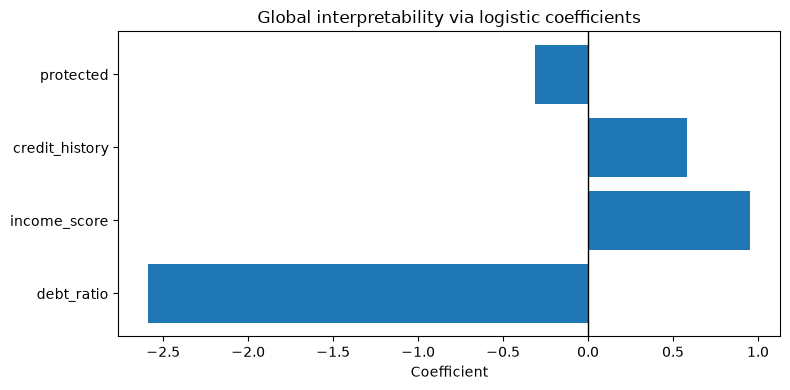

In [7]:
plt.figure(figsize=(8, 4))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Global interpretability via logistic coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()
        


## Connect to Theory

- Fairness metrics reveal distributional disparities that aggregate accuracy hides.
- Coefficients provide transparent global explanation for linear models.
- Governance implication: fairness and explanation reports should be versioned and reviewed before deployment.
        


## Safety & Security Case Studies & Exceptions

### Case Study A: Credit Model Governance
A lender integrated fairness dashboards into release approval, requiring sign-off on parity gaps and rationale for residual disparities.

### Case Study B: Healthcare Triage Explanation Requirement
A hospital required feature-level explanation visibility before clinical use, improving trust and error triage speed.

### Exception Pattern
For purely operational low-stakes scoring, exhaustive explainability may be unnecessary, but transparent monitoring and documentation are still needed.
        


## Interview Questions & Answers

1. **Q:** What is demographic parity?  
   **A:** Equality of positive prediction rates across groups.
2. **Q:** What is equal opportunity?  
   **A:** Equality of true positive rates across groups.
3. **Q:** Why can accuracy be misleading for fairness?  
   **A:** Aggregate accuracy can mask subgroup harms.
4. **Q:** Group vs individual fairness?  
   **A:** Group fairness compares aggregates; individual fairness compares similar individuals.
5. **Q:** Why keep protected attributes for evaluation?  
   **A:** Without them you cannot audit disparities.
6. **Q:** What is proxy bias?  
   **A:** Non-sensitive features can encode protected information.
7. **Q:** What is a model card?  
   **A:** Structured documentation of intended use, evaluation, and limitations.
8. **Q:** How does explainability help debugging?  
   **A:** It surfaces feature behavior that may indicate leakage or bias.
9. **Q:** Can fairness and performance conflict?  
   **A:** Yes; decisions require risk-aware trade-off management.
10. **Q:** What should be monitored post-deployment?  
    **A:** Fairness metrics, drift, user complaints, and subgroup error rates.
11. **Q:** What is practical governance minimum?  
    **A:** Ownership, documented thresholds, and incident escalation process.
        
